# Dataset plots

Visualization and threshold tuning for eye gesture event detection.

In [1]:
from pathlib import Path

from src.analyze import analyze_file
from src.blink_signal import has_blink_columns
from src.detection_config import DetectionConfig
from src.gaze_signal import has_gaze_columns
from src.io_utils import collect_csv_files
from src.plots import plot_blink_signal, plot_combined_overview, plot_detected_events, plot_gaze_speed

DATA_DIR = Path("data")
cfg = DetectionConfig()
files = collect_csv_files(DATA_DIR)
files[:5], len(files)

([PosixPath('data/SaccadeData_20260718_214312.csv'),
  PosixPath('data/SaccadeData_20260718_214328.csv'),
  PosixPath('data/SaccadeData_20260718_214356.csv')],
 3)

Threshold adjustments

In [2]:
cfg = DetectionConfig(
    fixation_speed_threshold_deg_s=30.0,
    saccade_speed_threshold_deg_s=120.0,
    blink_threshold=0.60,
)

In [3]:
sample_path = files[0]
df, events = analyze_file(sample_path, cfg)
sample_path.name, events.head()

('SaccadeData_20260718_214312.csv',
                        source_file      phase   gesture start_time_s  \
 0  SaccadeData_20260718_214312.csv  recording   saccade        0.368   
 1  SaccadeData_20260718_214312.csv  recording  fixation        0.469   
 2  SaccadeData_20260718_214312.csv  recording   saccade        2.263   
 3  SaccadeData_20260718_214312.csv  recording  fixation        2.318   
 4  SaccadeData_20260718_214312.csv  recording   saccade        3.967   
 
   end_time_s duration_ms  peak_value sample_count  
 0      0.446        78.0  285.914694            8  
 1      2.241      1772.0    9.873503          160  
 2      2.296        33.0  170.748372            4  
 3      3.934      1616.0    8.397354          146  
 4      3.989        22.0  189.498396            3  )

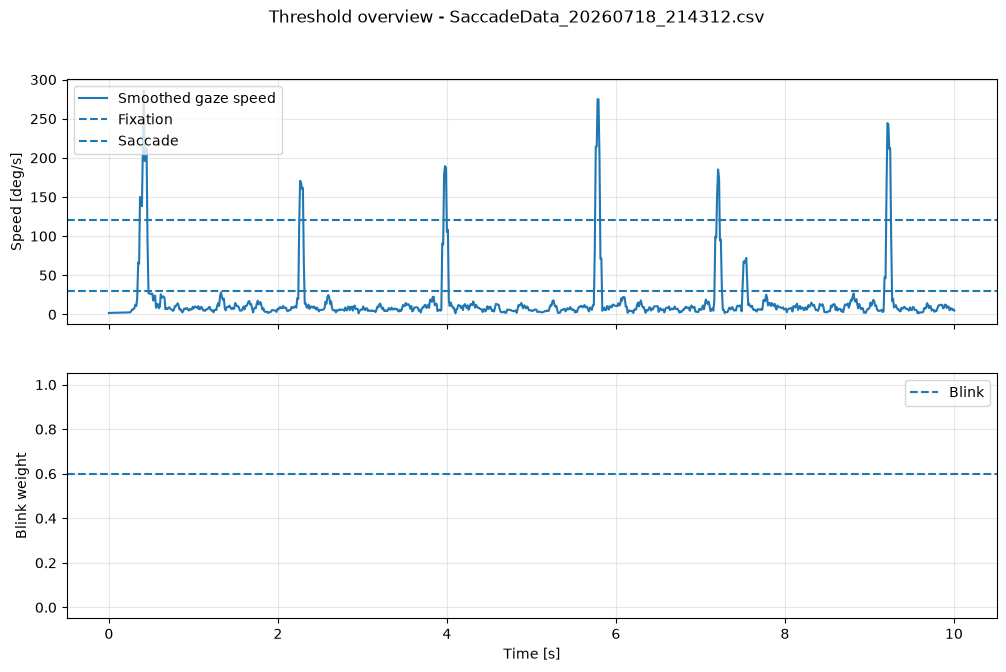

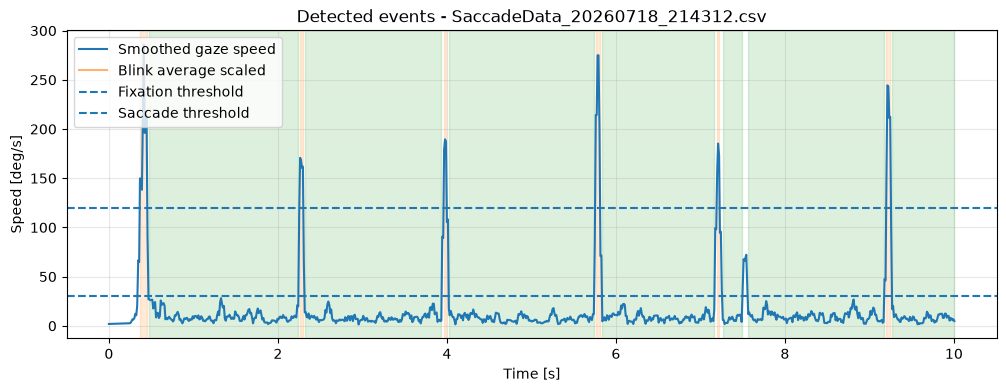

In [4]:
plot_combined_overview(df, cfg)
plot_detected_events(df, events, cfg);

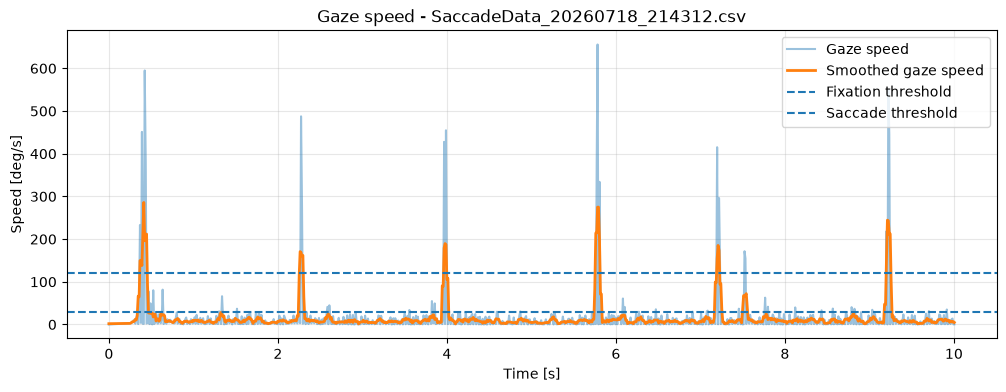

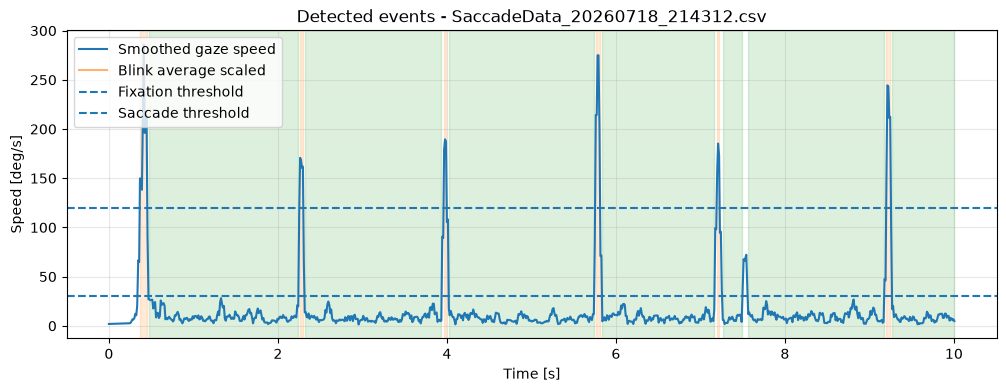

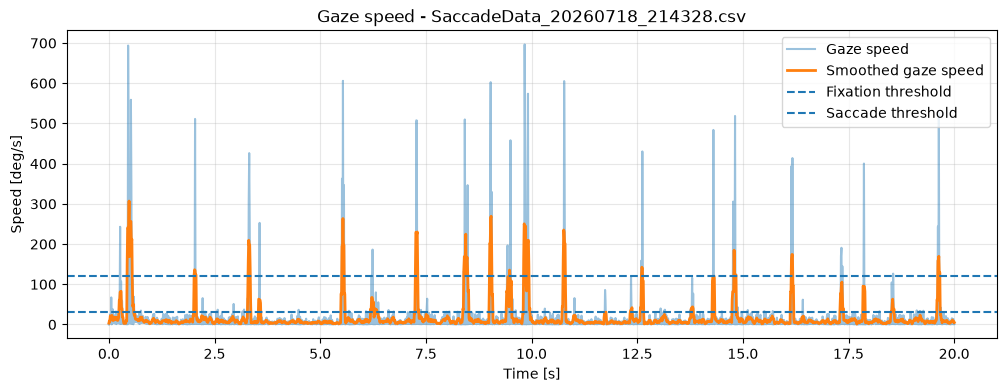

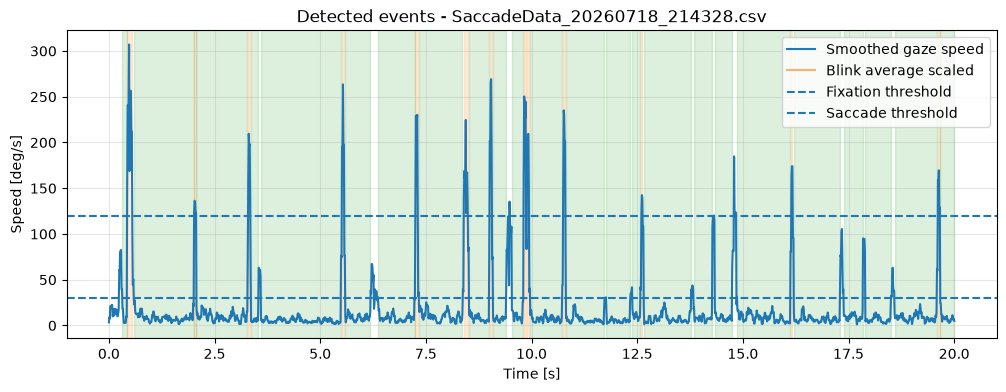

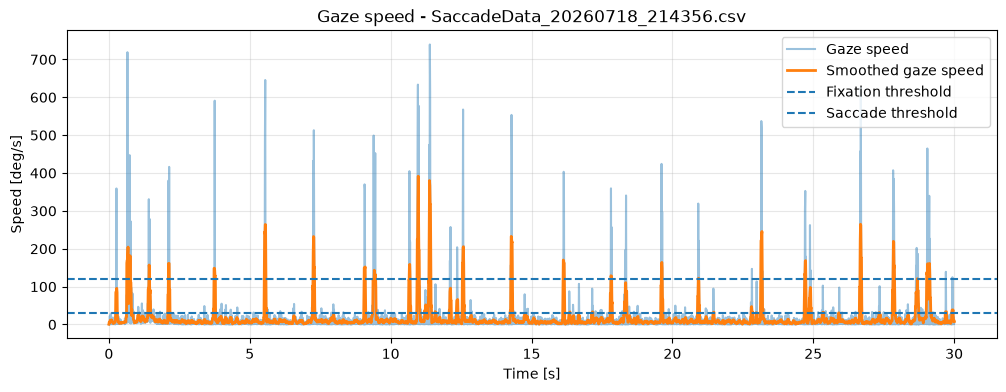

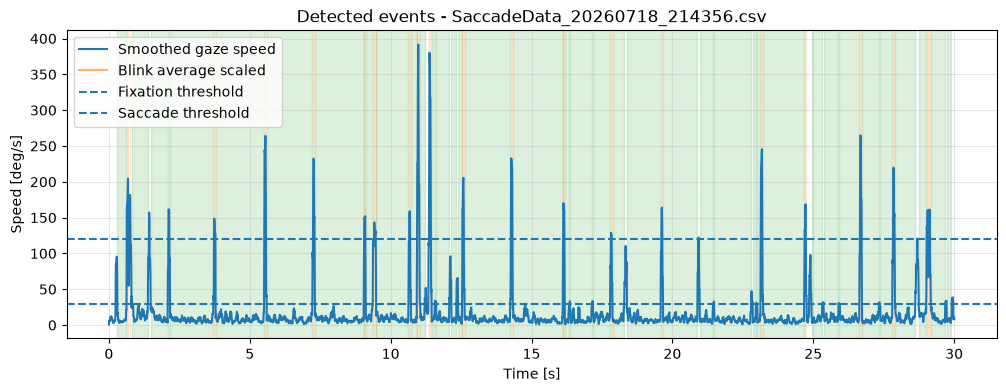

In [5]:
for path in files:
    df, events = analyze_file(path, cfg)
    if has_gaze_columns(df):
        plot_gaze_speed(df, cfg)
    if has_blink_columns(df):
        plot_blink_signal(df, cfg)
    plot_detected_events(df, events, cfg)